# Task 1- Data Cleaning And Preprocessing

# Data Collection and Loading

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# Load dataset 
df = pd.read_csv('C:/Users/ganes/Downloads/Travel_And_Tourism.csv')



In [33]:
# Inspect basic info
print("Dataset Shape:", df.shape)
print("\nData Types & Non-Null Counts:")
df.info()
print(df.head())
print("\nMissing Values Count:")
print(df.isnull().sum())

Dataset Shape: (1000, 13)

Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_Name         1000 non-null   object 
 1   Customer_Age          1000 non-null   int64  
 2   Gender                1000 non-null   object 
 3   Customer_Country      1000 non-null   object 
 4   Destination_Country   1000 non-null   object 
 5   Number_of_Travellers  995 non-null    float64
 6   Number_of_Adults      999 non-null    float64
 7   Number_of_Children    1000 non-null   int64  
 8   Hotel_Name            1000 non-null   object 
 9   Payment_Method        1000 non-null   object 
 10  Booking_Status        1000 non-null   object 
 11  Total_Trip_Cost       1000 non-null   int64  
 12  Transportation_Type   1000 non-null   object 
dtypes: float64(2), int64(3), object(8)
memory usage: 101.7+ KB
    Cust

In [34]:
df.describe(include='all')

,Customer_Name,Customer_Age,Gender,Customer_Country,Destination_Country,Number_of_Travellers,Number_of_Adults,Number_of_Children,Hotel_Name,Payment_Method,Booking_Status,Total_Trip_Cost,Transportation_Type
count,1000,1000.000000,1000,1000,1000,995.000000,999.000000,1000.000000,1000,1000,1000,1.000000e+03,1000
unique,956,NaN,2,11,10,NaN,NaN,NaN,78,6,4,NaN,3
top,Remy Darwish,NaN,Female,India,India,NaN,NaN,NaN,Cedar Heights,UPI,Completed,NaN,Flight
freq,2,NaN,568,655,669,NaN,NaN,NaN,25,297,772,NaN,682
mean,NaN,34.468000,NaN,NaN,NaN,5.648241,4.296296,1.366000,NaN,NaN,NaN,2.278389e+05,NaN
std,NaN,9.327914,NaN,NaN,NaN,3.317972,2.342920,1.593293,NaN,NaN,NaN,2.268066e+05,NaN
min,NaN,18.000000,NaN,NaN,NaN,1.000000,1.000000,0.000000,NaN,NaN,NaN,1.100000e+04,NaN
25%,NaN,26.000000,NaN,NaN,NaN,3.000000,2.000000,0.000000,NaN,NaN,NaN,8.160000e+04,NaN
50%,NaN,34.000000,NaN,NaN,NaN,5.000000,4.000000,1.000000,NaN,NaN,NaN,1.572000e+05,NaN
75%,NaN,42.000000,NaN,NaN,NaN,8.000000,5.000000,3.000000,NaN,NaN,NaN,2.832500e+05,NaN


# Data Cleaning

In [35]:
# Check for missing values
print(df.isnull().sum())

# Fill missing values or drop them if necessary
df.fillna(method='ffill', inplace=True)

# Check data types
print(df.dtypes)

Customer_Name           0
Customer_Age            0
Gender                  0
Customer_Country        0
Destination_Country     0
Number_of_Travellers    5
Number_of_Adults        1
Number_of_Children      0
Hotel_Name              0
Payment_Method          0
Booking_Status          0
Total_Trip_Cost         0
Transportation_Type     0
dtype: int64
Customer_Name            object
Customer_Age              int64
Gender                   object
Customer_Country         object
Destination_Country      object
Number_of_Travellers    float64
Number_of_Adults        float64
Number_of_Children        int64
Hotel_Name               object
Payment_Method           object
Booking_Status           object
Total_Trip_Cost           int64
Transportation_Type      object
dtype: object


C:\Users\ganes\AppData\Local\Temp\ipykernel_20984\2381406211.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [42]:
# Strategy 1: Fill numerical missing values with median
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Strategy 2: Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after imputation:", df.isnull().sum().sum())

Missing values after imputation: 0


In [36]:
# Convert data types if necessary
df['Age'] = df['Customer_Age'].astype(int)


# Encoding

In [46]:
# Label Encoding (for ordinal features or binary columns)
# Encode categorical variables
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df['Booking_Status'] = df['Booking_Status'].map({'Cancelled': 0, 'Completed': 1,'Pending':2})



# One-Hot Encoding (for nominal multi-category features)


# Outliers Detection

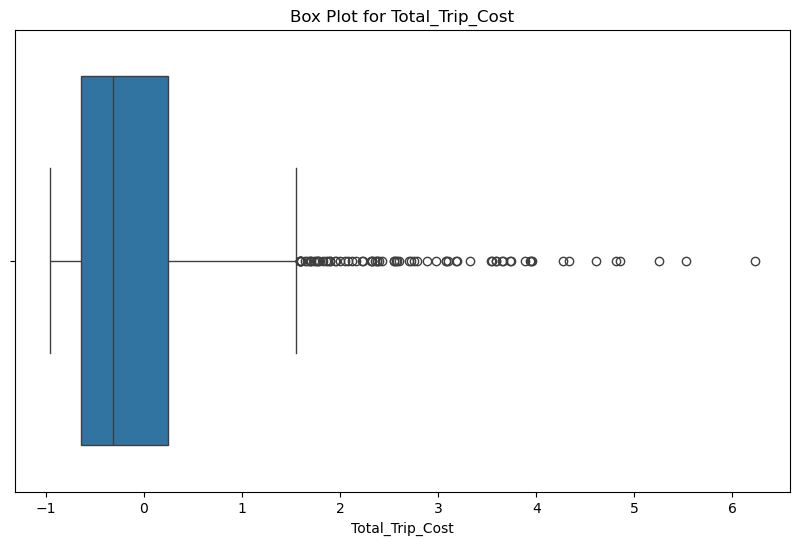

       Customer_Name  Customer_Age  Gender      Customer_Country  \
45     Mira Sterling     -1.551820     NaN                 India   
70       Isaac Joshi     -1.444561     NaN             Singapore   
77        Maaya Aziz     -1.444561     NaN             Australia   
83       Noah Bakshi     -1.444561     NaN  United Arab Emirates   
84   Nolan Takahashi     -1.444561     NaN                 India   
..               ...           ...     ...                   ...   
948       Nia Duarte      1.558684     NaN                 India   
973     Isaac Nguyen      1.665943     NaN                 India   
982     Lyra Qureshi      1.665943     NaN                 India   
983   Mateo Gonzalez      1.665943     NaN                 India   
990      Noor Vaughn      1.665943     NaN             Sri Lanka   

      Destination_Country  Number_of_Travellers  Number_of_Adults  \
45              Sri Lanka              1.612474          2.009881   
70                 France              0.1037

In [47]:


# Box plot for outlier detection in Total Trip Cost
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Total_Trip_Cost'])
plt.title('Box Plot for Total_Trip_Cost')
plt.show()

# Handling outliers (example: using IQR method)
q1 = df['Total_Trip_Cost'].quantile(0.25)
q3 = df['Total_Trip_Cost'].quantile(0.75)
iqr = q3 - q1

# Define outliers
outliers = df[(df['Total_Trip_Cost'] < (q1 - 1.5 * iqr)) | (df['Total_Trip_Cost'] > (q3 + 1.5 * iqr))]
print(outliers)
    

In [48]:
# Option A: Standardization (Z-Score Scaling -> Mean 0, Std 1)
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Option B: Normalization (Min-Max Scaling -> Range 0 to 1)
# min_max_scaler = MinMaxScaler()
# df[numerical_cols] = min_max_scaler.fit_transform(df[numerical_cols])

# Save preprocessed dataset
df.to_csv('clean_travel_dataset.csv', index=False)
print("Preprocessing complete! Saved clean dataset.")

Preprocessing complete! Saved clean dataset.


C:\Users\ganes\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\ganes\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\ganes\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
